# Modelagem Preditiva de Risco de Defasagem — Datathon FIAP

Este notebook tem como objetivo construir um modelo preditivo capaz de estimar a probabilidade de um aluno entrar em risco de defasagem, utilizando os indicadores educacionais da base PEDE.

Etapas:
- construção da base temporal de modelagem
- definição da variável target
- feature engineering
- tratamento de valores ausentes
- separação em treino e teste
- treinamento de modelos
- avaliação de desempenho
- interpretação dos resultados

## Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Configurações

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Carregamento da Base

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/RickPardono/Datathon_FIAP/refs/heads/main/data/processed/base_tratada.csv")
df.head()

,RA,Fase,Turma,ano,nome,ano_nascimento,idade,genero,ano_ingresso,instituicao_ensino,pedra,inde,num_avaliacoes,fase_ideal,defasagem,ian,iaa,ieg,ips,ida,ipv,mat,por,ing,ipp,pedra_ordem,num_notas_disponiveis,media_notas_disponiveis
0,RA-1,7,A,2022,Aluno-1,2003,19,Feminino,2016,Pública,Quartzo,5.783,4,8,-1,5.0,8.3,4.1,5.6,4.0,7.278,2.7,3.5,6.0,NaN,1.0,3,4.066667
1,RA-1,8,E,2023,Aluno-1,2003,20,Feminino,2016,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,RA-1,8,E,2024,Aluno-1,2003,21,Feminino,2021,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,RA-2,7,A,2022,Aluno-2,2005,17,Feminino,2017,Privada,Ametista,7.055,4,7,0,10.0,8.8,5.2,6.3,6.8,6.778,6.3,4.5,9.7,NaN,3.0,3,6.833333
4,RA-2,8,E,2023,Aluno-2,2005,18,Feminino,2017,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


## Visão geral inicial

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       3030 non-null   object 
 1   Fase                     3030 non-null   int64  
 2   Turma                    3030 non-null   object 
 3   ano                      3030 non-null   int64  
 4   nome                     3030 non-null   object 
 5   ano_nascimento           3030 non-null   int64  
 6   idade                    3030 non-null   int64  
 7   genero                   3030 non-null   object 
 8   ano_ingresso             3030 non-null   int64  
 9   instituicao_ensino       3029 non-null   object 
 10  pedra                    2845 non-null   object 
 11  inde                     2845 non-null   float64
 12  num_avaliacoes           3030 non-null   int64  
 13  fase_ideal               3030 non-null   int64  
 14  defasagem               

In [ ]:
df.isna().mean().sort_values(ascending=False).head(20)

,0
ing,0.639934
ipp,0.342574
inde,0.061056
pedra,0.061056
pedra_ordem,0.061056
por,0.061056
mat,0.060726
media_notas_disponiveis,0.059406
ipv,0.058746
ida,0.058746


## Copiar base

In [ ]:
df_model = df.copy()
print(df_model.shape)

(3030, 28)


## Filtrar apenas alunos com pelo menos 2 anos

In [ ]:
anos_por_aluno = df_model.groupby("RA")["ano"].nunique()
ra_validos = anos_por_aluno[anos_por_aluno >= 2].index

df_model = df_model[df_model["RA"].isin(ra_validos)].copy()
print(df_model.shape)

(2270, 28)


## Conferir distribuição de anos por aluno

In [ ]:
anos_por_aluno.value_counts().sort_index()

,count
ano,
1,760
2,433
3,468


## Construção da target

In [ ]:
df_model["defasagem_futuro"] = df_model.groupby("RA")["defasagem"].shift(-1)

In [ ]:
df_model["target_risco_defasagem"] = (df_model["defasagem_futuro"] < 0).astype("Int64")

## Remover linhas sem  target futura

In [ ]:
df_model = df_model.dropna(subset=["defasagem_futuro"]).copy()
print(df_model.shape)

(1369, 30)


## Conferir distribuição da target

In [ ]:
df_model["target_risco_defasagem"].value_counts()

,count
target_risco_defasagem,
0,694
1,675


In [ ]:
df_model["target_risco_defasagem"].value_counts(normalize=True)

,proportion
target_risco_defasagem,
0,0.506939
1,0.493061


## Feature Engineering Temporal

### Criar variáveis anteriores

In [ ]:
cols_prev = ["ida", "ieg", "ipv", "ips", "iaa", "ian", "inde", "defasagem"]

for col in cols_prev:
    df_model[f"{col}_prev"] = df_model.groupby("RA")[col].shift(1)

### Preencher alguns _prev com valor atual

In [ ]:
for col in ["ida", "ieg", "ipv", "ian", "inde", "defasagem", "iaa", "ips"]:
    df_model[f"{col}_prev"] = df_model[f"{col}_prev"].fillna(df_model[col])

### Criar deltas

In [ ]:
df_model["delta_ida"] = df_model["ida"] - df_model["ida_prev"]
df_model["delta_ieg"] = df_model["ieg"] - df_model["ieg_prev"]
df_model["delta_ipv"] = df_model["ipv"] - df_model["ipv_prev"]
df_model["delta_inde"] = df_model["inde"] - df_model["inde_prev"]

### Criar tempo no programa

In [ ]:
df_model["tempo_programa"] = df_model["ano"] - df_model["ano_ingresso"]

### Criar score exploratório de risco

In [ ]:
df_model["score_risco_eda"] = (
    (df_model["ida"] < 6).astype(int) +
    (df_model["ipv"] < 7).astype(int)
)

# ipp poderia entrar nesse score, porém apresenta ausência completa de valores em 2022

## Tratamento estratégico de missing

In [ ]:
df_model["flag_iaa_missing"] = df_model["iaa"].isna().astype(int)
df_model["flag_inde_missing"] = df_model["inde"].isna().astype(int)
df_model["flag_ida_missing"] = df_model["ida"].isna().astype(int)
df_model["flag_ipv_missing"] = df_model["ipv"].isna().astype(int)
df_model["flag_ieg_missing"] = df_model["ieg"].isna().astype(int)
df_model["flag_pedra_missing"] = df_model["pedra"].isna().astype(int)

## Remover variáveis que não entrarão na modelagem

In [ ]:
df_model = df_model.drop(
    columns=["ing", "ipp", "defasagem_futuro"],
    errors="ignore"
)

## Conferir missing após correções

In [ ]:
df_model.isna().sum().sort_values(ascending=False).head(30)

,0
pedra,75
inde,75
pedra_ordem,75
delta_inde,75
delta_ipv,72
ieg,72
por,72
mat,72
media_notas_disponiveis,72
ida,72


## Tratamento dos valores ausentes

Os valores ausentes foram tratados de forma híbrida:
- criação de flags para ausência observacional em variáveis importantes;
- preenchimento parcial de algumas variáveis temporais anteriores com o valor atual, apenas quando o histórico não existia;
- remoção de variáveis com ausência estrutural incompatível com o split temporal, como o IPP;
- imputação final realizada no pipeline de modelagem.

Essa estratégia permite preservar informação útil sem eliminar grande quantidade de observações e evita viés entre treino e teste.

## Seleção de features

In [ ]:
features = [
    "idade",
    "ano",
    "ano_ingresso",
    "tempo_programa",
    "num_avaliacoes",
    "num_notas_disponiveis",
    "media_notas_disponiveis",
    "ian",
    "iaa",
    "ieg",
    "ips",
    "ida",
    "ipv",
    "inde",
    "defasagem",
    "score_risco_eda",
    "ida_prev",
    "ieg_prev",
    "ipv_prev",
    "ips_prev",
    "iaa_prev",
    "ian_prev",
    "inde_prev",
    "defasagem_prev",
    "delta_ida",
    "delta_ieg",
    "delta_ipv",
    "delta_inde",
    "pedra",
    "pedra_ordem",
    "instituicao_ensino",
    "genero",
    "flag_iaa_missing",
    "flag_inde_missing",
    "flag_ida_missing",
    "flag_ipv_missing",
    "flag_ieg_missing",
    "flag_pedra_missing"
]

target = "target_risco_defasagem"

## Montar base final de modelagem

In [ ]:
df_ml = df_model[features + [target]].copy()
print(df_ml.shape)
df_ml.head()

(1369, 39)


,idade,ano,ano_ingresso,tempo_programa,num_avaliacoes,num_notas_disponiveis,media_notas_disponiveis,ian,iaa,ieg,ips,ida,ipv,inde,defasagem,score_risco_eda,ida_prev,ieg_prev,ipv_prev,ips_prev,iaa_prev,ian_prev,inde_prev,defasagem_prev,delta_ida,delta_ieg,delta_ipv,delta_inde,pedra,pedra_ordem,instituicao_ensino,genero,flag_iaa_missing,flag_inde_missing,flag_ida_missing,flag_ipv_missing,flag_ieg_missing,flag_pedra_missing,target_risco_defasagem
0,19,2022,2016,6,4,3,4.066667,5.0,8.3,4.1,5.6,4.0,7.278,5.783,-1,1,4.0,4.1,7.278,5.6,8.3,5.0,5.783,-1.0,0.0,0.0,0.0,0.0,Quartzo,1.0,Pública,Feminino,0,0,0,0,0,0,0
1,20,2023,2016,7,0,0,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,4.0,4.1,7.278,5.6,8.3,5.0,5.783,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,Privada com bolsa/apadrinhamento,Feminino,1,1,1,1,1,1,0
3,17,2022,2017,5,4,3,6.833333,10.0,8.8,5.2,6.3,6.8,6.778,7.055,0,1,6.8,5.2,6.778,6.3,8.8,10.0,7.055,0.0,0.0,0.0,0.0,0.0,Ametista,3.0,Privada,Feminino,0,0,0,0,0,0,0
4,18,2023,2017,6,0,0,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,6.8,5.2,6.778,6.3,8.8,10.0,7.055,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Privada com bolsa/apadrinhamento,Feminino,1,1,1,1,1,1,0
8,17,2022,2016,6,4,3,5.200000,10.0,7.9,8.6,5.6,5.2,7.389,7.427,0,1,5.2,8.6,7.389,5.6,7.9,10.0,7.427,0.0,0.0,0.0,0.0,0.0,Ametista,3.0,Privada,Feminino,0,0,0,0,0,0,0


## Conferir missing da base final

In [ ]:
df_ml.isna().sum().sort_values(ascending=False).head(30)

,0
pedra_ordem,75
delta_inde,75
inde,75
pedra,75
media_notas_disponiveis,72
ieg,72
delta_ida,72
delta_ipv,72
delta_ieg,72
ida,72


## Split temporal

In [ ]:
train = df_ml[df_ml["ano"] == 2022].copy()
test = df_ml[df_ml["ano"] == 2023].copy()

## Separar X e y

In [ ]:
X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

## Conferir balanceamento

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target_risco_defasagem
1    0.607616
0    0.392384
Name: proportion, dtype: Float64
target_risco_defasagem
0    0.597386
1    0.402614
Name: proportion, dtype: Float64


## Pré-processamento

### Separar colunas numéricas e categóricas

In [ ]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols[:10], "...")

Categóricas: ['pedra', 'instituicao_ensino', 'genero']
Numéricas: ['idade', 'ano', 'ano_ingresso', 'tempo_programa', 'num_avaliacoes', 'num_notas_disponiveis', 'media_notas_disponiveis', 'ian', 'iaa', 'ieg'] ...


### Definir preprocessador

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

## Modelos

Nesta etapa, são treinados três modelos base para comparação inicial:
- Regressão Logística
- Random Forest
- XGBoost

O objetivo é identificar qual abordagem apresenta melhor desempenho antes de qualquer ajuste de hiperparâmetros.

### Logistic Regression

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade', 'ano',
                                                   'ano_ingresso',
                                                   'tempo_programa',
                                                   'num_avaliacoes',
                                                   'num_notas_disponiveis',
                                                   'media_notas_disponiveis',
                                                   'ian', 'iaa', 'ieg', 'ips',
                                                   'ida', 'ipv', 'inde',
                                                   'defasagem',
                                                   'score_risco_eda',
                                                   '...
                                                   'defasagem_prev',
                                                   'delta_ida', 'delta_ieg',
                                                   'delta_ipv', 'delta_inde',
                                                   'pedra_ordem',
                                                   'flag_iaa_missing', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pedra',
                                                   'instituicao_ensino',
                                                   'genero'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

### Avaliar Logistic Regression

In [ ]:
y_proba_log = log_model.predict_proba(X_test)[:, 1]
y_pred_log = (y_proba_log >= 0.5).astype(int)

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.73      0.84      0.78       457
         1.0       0.69      0.54      0.60       308

    accuracy                           0.72       765
   macro avg       0.71      0.69      0.69       765
weighted avg       0.71      0.72      0.71       765

ROC-AUC: 0.756649805336895
[[383  74]
 [143 165]]


### Random Forest

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade', 'ano',
                                                   'ano_ingresso',
                                                   'tempo_programa',
                                                   'num_avaliacoes',
                                                   'num_notas_disponiveis',
                                                   'media_notas_disponiveis',
                                                   'ian', 'iaa', 'ieg', 'ips',
                                                   'ida', 'ipv', 'inde',
                                                   'defasagem',
                                                   'score_risco_eda',
                                                   '...
                                                   'delta_ida', 'delta_ieg',
                                                   'delta_ipv', 'delta_inde',
                                                   'pedra_ordem',
                                                   'flag_iaa_missing', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pedra',
                                                   'instituicao_ensino',
                                                   'genero'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

### Avaliar Random Forest

In [ ]:
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.84      0.67      0.74       457
         1.0       0.62      0.81      0.70       308

    accuracy                           0.72       765
   macro avg       0.73      0.74      0.72       765
weighted avg       0.75      0.72      0.72       765

ROC-AUC: 0.8375877404870841
[[304 153]
 [ 60 248]]


### XGBoost

In [ ]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade', 'ano',
                                                   'ano_ingresso',
                                                   'tempo_programa',
                                                   'num_avaliacoes',
                                                   'num_notas_disponiveis',
                                                   'media_notas_disponiveis',
                                                   'ian', 'iaa', 'ieg', 'ips',
                                                   'ida', 'ipv', 'inde',
                                                   'defasagem',
                                                   'score_risco_eda',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Avaliar XGBoost

In [ ]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80       457
         1.0       0.70      0.76      0.73       308

    accuracy                           0.77       765
   macro avg       0.76      0.77      0.76       765
weighted avg       0.77      0.77      0.77       765

ROC-AUC: 0.8390690272528347
[[356 101]
 [ 75 233]]


## Comparação dos modelos



### Curva ROC

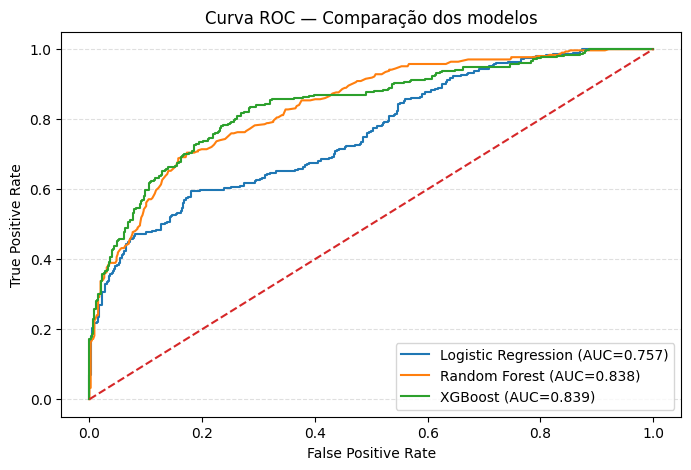

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8,5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_log):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("Curva ROC — Comparação dos modelos")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

## Otimização do XGBoost

Como o XGBoost apresentou o melhor desempenho na etapa baseline, ele foi selecionado para ajuste de hiperparâmetros.

A otimização foi realizada com GridSearchCV e validação cruzada aplicada apenas no conjunto de treino, mantendo o conjunto de teste temporal completamente intocado para avaliação final.

In [ ]:
xgb_model_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid_xgb = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 4, 6],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_model_tuning,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Melhores parâmetros:", grid_xgb.best_params_)
print("Melhor ROC-AUC CV:", grid_xgb.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores parâmetros: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Melhor ROC-AUC CV: 0.8694951764647187


## Melhor XGBoost

In [ ]:
best_xgb = grid_xgb.best_estimator_

## Avaliação do XGBoost otimizado

In [ ]:
y_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best_xgb = (y_proba_best_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_best_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best_xgb))
print(confusion_matrix(y_test, y_pred_best_xgb))

              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81       457
         1.0       0.71      0.77      0.74       308

    accuracy                           0.78       765
   macro avg       0.77      0.78      0.77       765
weighted avg       0.78      0.78      0.78       765

ROC-AUC: 0.8493989599022422
[[359  98]
 [ 72 236]]


## Curva ROC final

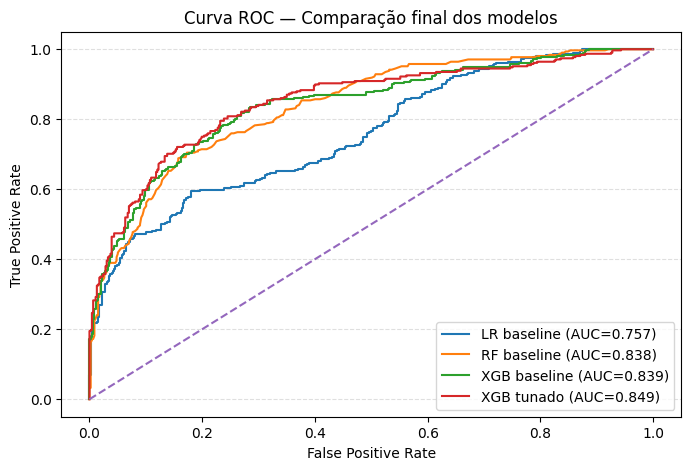

In [ ]:
fpr_best_xgb, tpr_best_xgb, _ = roc_curve(y_test, y_proba_best_xgb)

plt.figure(figsize=(8,5))
plt.plot(fpr_log, tpr_log, label=f"LR baseline (AUC={roc_auc_score(y_test, y_proba_log):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF baseline (AUC={roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB baseline (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot(fpr_best_xgb, tpr_best_xgb, label=f"XGB tunado (AUC={roc_auc_score(y_test, y_proba_best_xgb):.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("Curva ROC — Comparação final dos modelos")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

## Importâncias das features do modelo final

In [ ]:
xgb_clf = best_xgb.named_steps["classifier"]
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

importancias = pd.Series(xgb_clf.feature_importances_, index=feature_names).sort_values(ascending=False)
importancias.head(20)

,0
num__ian,0.164208
num__defasagem,0.088355
num__ipv_prev,0.064217
cat__instituicao_ensino_Privada,0.062020
num__num_notas_disponiveis,0.057780
num__num_avaliacoes,0.054361
num__ipv,0.050112
num__defasagem_prev,0.049770
num__ian_prev,0.044466
num__inde_prev,0.035487


## Plot das importâncias

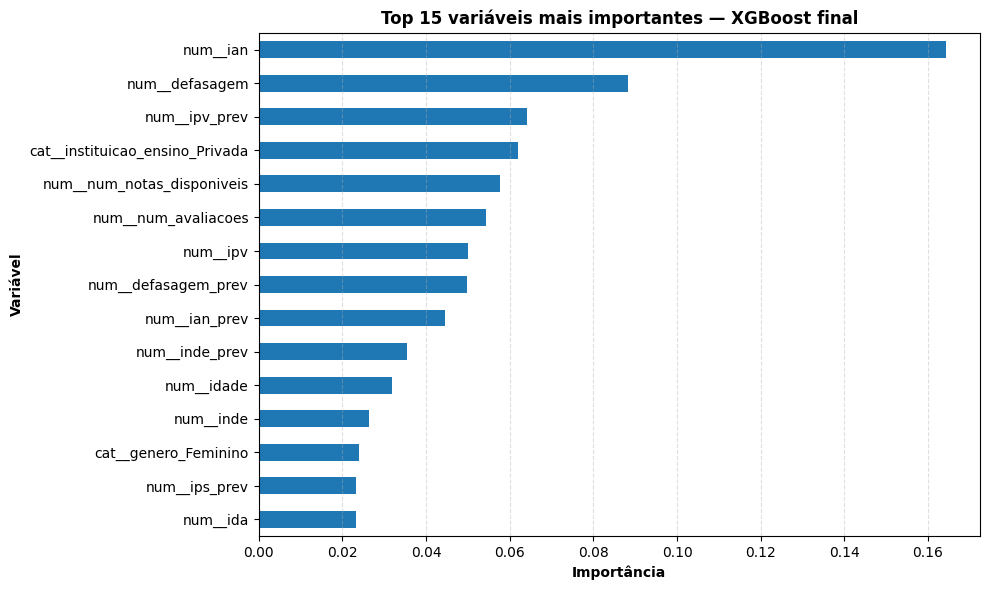

In [ ]:
plt.figure(figsize=(10,6))
importancias.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 variáveis mais importantes — XGBoost final", weight="bold")
plt.xlabel("Importância", weight="bold")
plt.ylabel("Variável", weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Salvar o modelo final

In [ ]:
# Caminho para pasta models (fora de notebooks)
output_path = Path("../models/model.joblib")

# Criar pasta se não existir
output_path.parent.mkdir(parents=True, exist_ok=True)

# Salvar modelo final (XGBoost tunado)
joblib.dump(best_xgb, output_path)

print(f"Modelo salvo em: {output_path.resolve()}")

Modelo salvo em: /models/model.joblib


## Resultado do conjunto de teste

In [ ]:
id_col = "RA" if "RA" in df_model.columns else "ra"
cols_exibir_base = [id_col, "ano", "ida", "ieg", "ipv", "defasagem"]

resultado_teste = df_model.loc[test.index, cols_exibir_base].copy()
resultado_teste["y_true"] = y_test.values
resultado_teste["risco_predito"] = y_proba_best_xgb

resultado_teste["faixa_risco"] = pd.cut(
    resultado_teste["risco_predito"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["Baixo", "Moderado", "Alto", "Crítico"],
    include_lowest=True
)

resultado_teste.head()

,RA,ano,ida,ieg,ipv,defasagem,y_true,risco_predito,faixa_risco
1,RA-1,2023,NaN,NaN,NaN,0,0,0.107182,Baixo
4,RA-2,2023,NaN,NaN,NaN,0,0,0.116216,Baixo
11,RA-6,2023,NaN,NaN,NaN,0,0,0.128916,Baixo
14,RA-7,2023,NaN,NaN,NaN,0,0,0.123951,Baixo
21,RA-12,2023,NaN,NaN,NaN,0,0,0.117612,Baixo


## Alunos com maior risco

In [ ]:
resultado_teste.sort_values("risco_predito", ascending=False).head(20)

,RA,ano,ida,ieg,ipv,defasagem,y_true,risco_predito,faixa_risco
1844,RA-822,2023,7.1,8.4,5.925000,-2,1,0.989706,Crítico
546,RA-262,2023,3.8,3.7,6.050000,-2,1,0.986501,Crítico
1138,RA-529,2023,6.8,9.6,6.893333,-2,1,0.986256,Crítico
1358,RA-623,2023,7.3,9.5,7.446667,-2,1,0.985671,Crítico
1547,RA-704,2023,6.1,9.9,6.265000,-2,1,0.985504,Crítico
963,RA-454,2023,2.6,7.5,5.540000,-2,1,0.984947,Crítico
2167,RA-995,2023,5.1,7.9,7.180000,-2,1,0.984141,Crítico
1693,RA-762,2023,5.8,9.1,7.670000,-2,1,0.983227,Crítico
1064,RA-497,2023,3.5,8.7,6.885000,-2,1,0.983188,Crítico
1588,RA-719,2023,5.9,5.3,7.095000,-2,1,0.982944,Crítico
